In [ ]:
##Step 1 Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Step 2 Load and Explore Dataset
# Load Titanic dataset from GitHub
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Quick look at the data
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
##Step3 Handle missing values
print("Missing values:\n", df.isnull().sum())

# Fill missing Age values with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked values with the most common port
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column (too many missing values)
df.drop(columns=['Cabin'], inplace=True)

# Confirm no missing values remain
print("Missing values after cleaning:\n", df.isnull().sum())

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Missing values after cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipython-input-1969069673.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-1969069673.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
##Step 4 Datatype Conversion
# Convert 'Pclass', 'Survived', 'Sex', 'Embarked' to categorical type
df['Pclass'] = df['Pclass'].astype('category')
df['Survived'] = df['Survived'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(4), float64(2), int64(3), object(2)
memory usage: 52.8+ KB


In [ ]:
##Step 5 Summary Statistics
# Basic statistics for numerical columns
print(df.describe())

# Summary for categorical columns
print(df.describe(include='category'))

       PassengerId         Age       SibSp       Parch        Fare
count   891.000000  891.000000  891.000000  891.000000  891.000000
mean    446.000000   29.361582    0.523008    0.381594   32.204208
std     257.353842   13.019697    1.102743    0.806057   49.693429
min       1.000000    0.420000    0.000000    0.000000    0.000000
25%     223.500000   22.000000    0.000000    0.000000    7.910400
50%     446.000000   28.000000    0.000000    0.000000   14.454200
75%     668.500000   35.000000    1.000000    0.000000   31.000000
max     891.000000   80.000000    8.000000    6.000000  512.329200
        Survived  Pclass   Sex Embarked
count        891     891   891      891
unique         2       3     2        3
top            0       3  male        S
freq         549     491   577      646


In [ ]:
##  Step 6 Survival Analysis
# Ensure Survived is numeric for calculations
df['Survived'] = df['Survived'].astype(int)

# Survival rate by Gender
print("Survival rate by Gender:")
print(df.groupby('Sex')['Survived'].mean())

# Survival rate by Passenger Class
print("\nSurvival rate by Passenger Class:")
print(df.groupby('Pclass')['Survived'].mean())

# Survival by Gender and Class
print("\nSurvival rate by Gender and Class:")
print(df.groupby(['Pclass','Sex'])['Survived'].mean())

Survival rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by Passenger Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival rate by Gender and Class:
Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64


/tmp/ipython-input-1496026264.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Sex')['Survived'].mean())
/tmp/ipython-input-1496026264.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Pclass')['Survived'].mean())
/tmp/ipython-input-1496026264.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['Pclass','Sex'])['Survived'].mean())


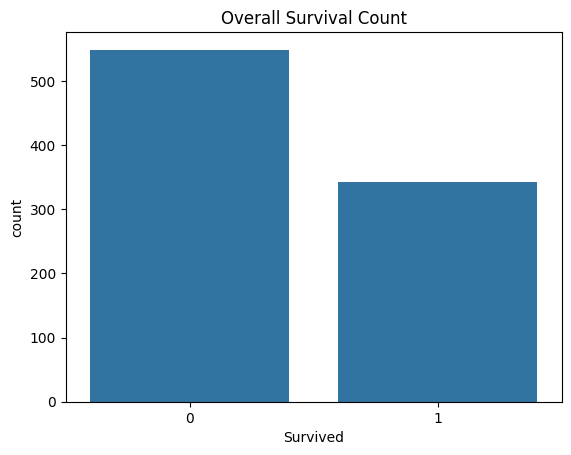

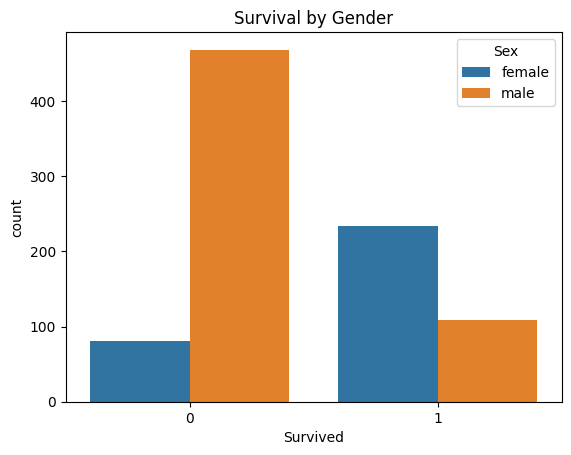

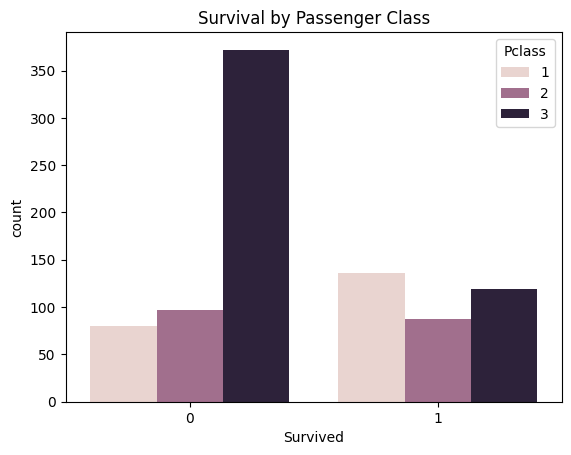

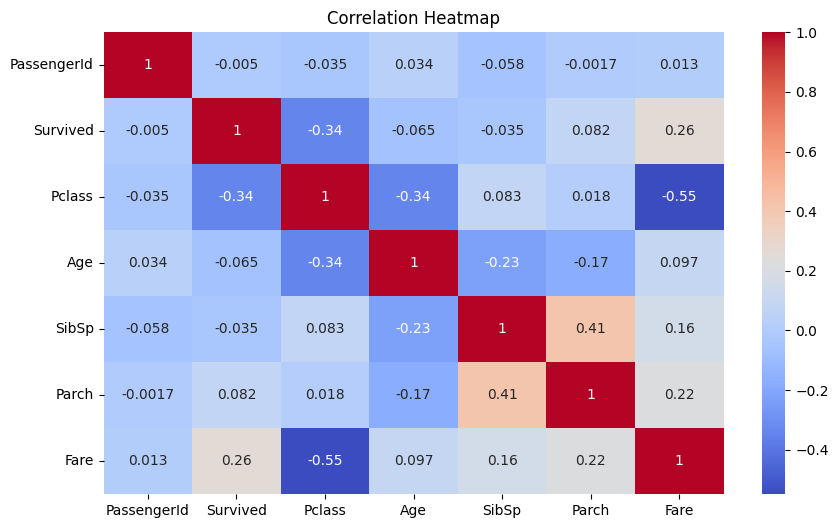

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Survived, Pclass are numeric for plotting correlations if needed
df['Survived'] = df['Survived'].astype(int)
df['Pclass'] = df['Pclass'].astype(int)

# 1️⃣ Bar plot: Overall Survival Count
sns.countplot(x='Survived', data=df)
plt.title('Overall Survival Count')
plt.show()

# 2️⃣ Bar plot: Survival by Gender
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival by Gender')
plt.show()

# 3️⃣ Bar plot: Survival by Passenger Class
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title('Survival by Passenger Class')
plt.show()

# 4️⃣ Correlation heatmap (numeric columns only)
plt.figure(figsize=(10,6))
numeric_cols = df.select_dtypes(include=['int64','float64'])  # only numeric
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

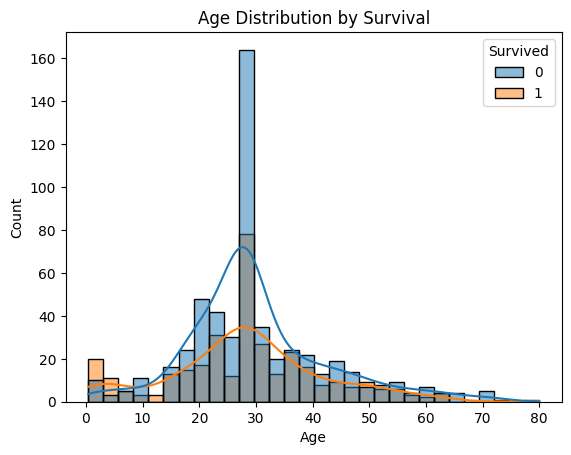

In [ ]:
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
plt.title('Age Distribution by Survival')
plt.show()

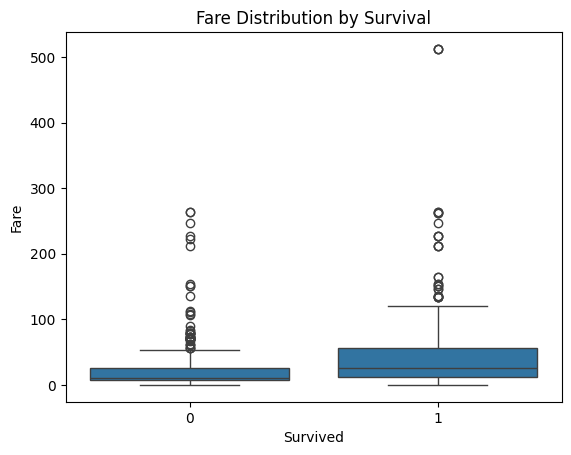

In [ ]:
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.show()

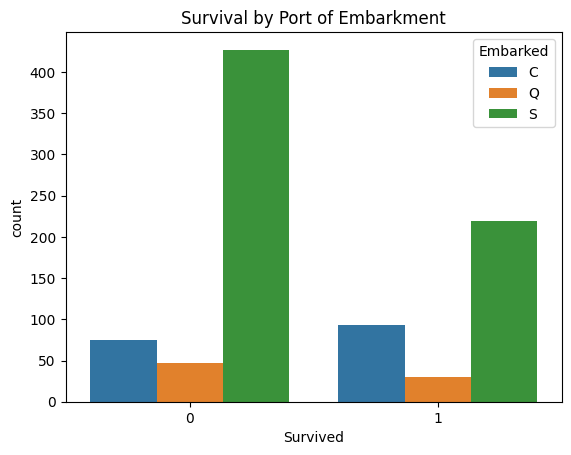

In [ ]:
##Step 7 Data Visualization
sns.countplot(x='Survived', hue='Embarked', data=df)
plt.title('Survival by Port of Embarkment')
plt.show()

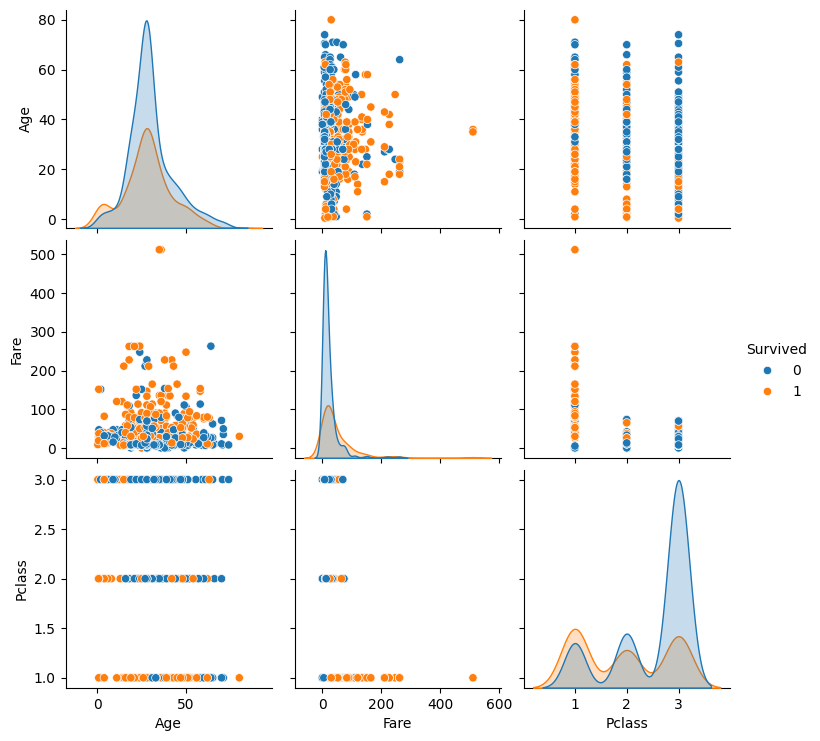

In [ ]:
sns.pairplot(df[['Survived','Age','Fare','Pclass']], hue='Survived')
plt.show()

In [ ]:
# Step 8: Export Cleaned Data
df.to_csv('titanic_cleaned.csv', index=False)
print("✅ Cleaned Titanic dataset has been saved successfully as 'titanic_cleaned.csv'")

✅ Cleaned Titanic dataset has been saved successfully as 'titanic_cleaned.csv'


## Step 9: Insights Summary
- Around 38% of passengers survived.
- Females had a much higher survival rate than males.
- 1st class passengers had the highest survival chances.
- Higher fares were linked to higher survival rates.
- Passengers from Southampton port survived the most.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Load dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)

# Convert categorical to numeric
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])          # female=0, male=1
df['Embarked'] = le.fit_transform(df['Embarked'])# C=0,Q=1,S=2

# Features (X) and target (y)
X = df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
y = df['Survived']

# Split into train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale data (important for KNN & SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.8044692737430168


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy'
)

grid_knn.fit(X_train_scaled, y_train)

print("Best KNN Parameters:", grid_knn.best_params_)
print("Best KNN Accuracy:", grid_knn.best_score_)


Best KNN Parameters: {'n_neighbors': 11}
Best KNN Accuracy: 0.8159952723333005


In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.8156424581005587


In [ ]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(
    SVC(),
    param_grid_svm,
    cv=5,
    scoring='accuracy'
)

grid_svm.fit(X_train_scaled, y_train)

print("Best SVM Parameters:", grid_svm.best_params_)
print("Best SVM Accuracy:", grid_svm.best_score_)


Best SVM Parameters: {'C': 1, 'kernel': 'rbf'}
Best SVM Accuracy: 0.8215896779277061


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=6, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))


Decision Tree Accuracy: 0.8044692737430168


In [ ]:
param_grid_tree = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree,
    cv=5,
    scoring='accuracy'
)

grid_tree.fit(X_train, y_train)

print("Best Decision Tree Parameters:", grid_tree.best_params_)
print("Best Decision Tree Accuracy:", grid_tree.best_score_)


Best Decision Tree Parameters: {'max_depth': 3, 'min_samples_split': 2}
Best Decision Tree Accuracy: 0.8202107751403526


In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8044692737430168


In [ ]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='accuracy'
)

grid_lr.fit(X_train_scaled, y_train)

print("Best Logistic Regression Parameters:", grid_lr.best_params_)
print("Best Logistic Regression Accuracy:", grid_lr.best_score_)


Best Logistic Regression Parameters: {'C': 0.01}
Best Logistic Regression Accuracy: 0.8075642667191962


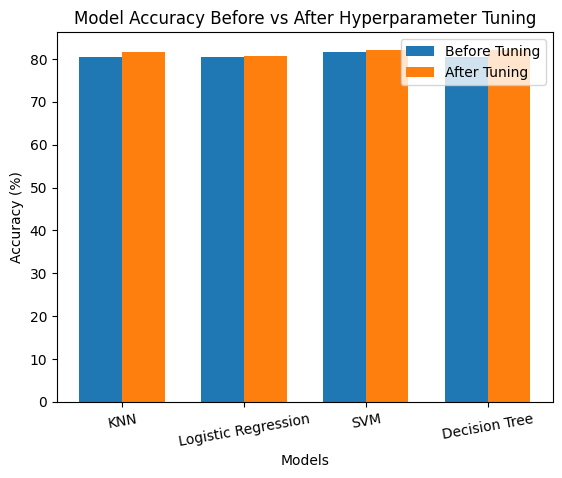

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['KNN', 'Logistic Regression', 'SVM', 'Decision Tree']

before_tuning = [80.44, 80.44, 81.56, 80.44]
after_tuning = [81.59, 80.75, 82.15, 82.02]

x = np.arange(len(models))
width = 0.35

plt.figure()
plt.bar(x - width/2, before_tuning, width, label='Before Tuning')
plt.bar(x + width/2, after_tuning, width, label='After Tuning')

plt.xticks(x, models, rotation=10)
plt.ylabel('Accuracy (%)')
plt.xlabel('Models')
plt.title('Model Accuracy Before vs After Hyperparameter Tuning')
plt.legend()
plt.show()
